# Prepare GSA (genotyping array) data for the GWAS notebook

This notebook turns the raw GSA files in `data/XDP/vcf/GSA/raw_per_chr/` (1,652 samples
across multiple projects, imputed with IMPUTE5, per-chromosome BCFs) into the inputs the
main GWAS notebook (`metric_corr_with_GWAS_only_diseased_XDP.ipynb`) expects:

1. **Filter** the array down to the XDP cohort only (samples named `SCF-*`/`PCMC-*`),
   and **rename** them to match `original_donor_id` in the snRNA-seq `adata` so they
   merge cleanly downstream (same convention the WGS pipeline relies on).
2. **Kinship-based relatedness pruning**, computed as early as possible (right after
   the per-chromosome subset/rename), so related donors never enter either of the
   downstream outputs below — not just flagged for the main notebook to filter later.
3. **Candidate-region VCF** for the two GWAS genes (`MSH3`, `PMS2`), normalized and
   filtered on imputation quality — a drop-in replacement for the WGS notebook's
   `SUBSET_NORM_VCF`.
4. **Ancestry PCA**, computed on the full XDP cohort minus the related donors dropped
   in step 2, mirroring the WGS notebook's PCA cell but scoped to GSA samples.

Differences from the WGS pipeline that this notebook exists to handle:
- GSA is **imputed** (IMPUTE5), so every site carries an `INFO` quality score; WGS has no
  such field. We filter on it (lenient for the candidate region, strict for PCA/kinship).
- GSA contigs are already `chr`-prefixed GRCh38, unlike the raw WGS VCF — no chromosome
  rename step needed.
- The GSA array bundles ~1,650 samples from unrelated projects; only ~95 are XDP
  (identified by `SCF-`/`PCMC-` naming), and those carry a tissue-region suffix
  (e.g. `SCF-18-003_CB-Lobule4`) that isn't present in `adata.obs["original_donor_id"]`.
- The GSA imputation panel includes a handful of structural-variant records with
  symbolic ALT alleles (`<DEL>`, `<INS:ME:ALU>`...) that `bcftools norm` can't
  left-align — WGS has none of these. We drop them before normalizing.


## Config

In [24]:
import subprocess, os, re, shutil
import pandas as pd
import numpy as np

VCF_FOLDER = "/home/gdallagl/myworkdir/XDP/data/XDP/vcf"
MOUNT = VCF_FOLDER

IMAGE_BCFTOOLS = "quay.io/biocontainers/bcftools:1.21--h8b25389_0"
IMAGE_PLINK    = "quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0"
N_THREADS = 16

GSA_RAW_DIR      = "GSA/raw_per_chr"
GSA_RAW_TEMPLATE = "gsa.mclean_gsamd3.chr{chrom}.as.bcf"
AUTOSOMES  = [str(i) for i in range(1, 23)]
ALL_CHROMS = AUTOSOMES + ["X"]

GENES_BED = ["MSH3", "PMS2"]
GENOME    = "GRCh38"
FLANK     = 20000

FASTA          = "fasta_genome/GRCh38.fasta"                 # same reference used by the WGS notebook
LRLD_FILE      = "fasta_genome/long_range_ld_GRCh38.txt"      # already written by the WGS notebook; reused as-is

# Imputation-quality filters. GSA is imputed (IMPUTE5), so unlike WGS every site carries
# an INFO/INFO quality score in [0,1]; directly-genotyped (non-imputed) sites are always INFO=1.
INFO_MIN_GWAS = 0.3   # lenient: candidate-region variants -> don't want to lose real signal
PCA_USE_GENOTYPED_ONLY = True  # recommended: PCA/kinship on directly-typed array SNPs only
                                # (fast, no imputation noise; ~genome-wide typed marker set).
                                # If False, falls back to an INFO-score threshold instead:
INFO_MIN_PCA = 0.8

KINSHIP_FILTER = 0.0442  # KING kinship threshold, ~3rd-degree relative or closer (same as WGS notebook)

# ---- GSA-specific output layout (mirrors whole_xdp_norm / subset / whole_xdp_PCA used for WGS) ----
XDP_PER_CHR_DIR = "GSA/xdp_only_per_chr"   # per-chr, sample-subset + renamed to original_donor_id
ID_MAP_DIR      = "GSA/id_mapping"
SUBSET_DIR      = "GSA/subset"             # candidate-gene output (mirrors WGS notebook's "subset/")
PCA_DIR         = "GSA/whole_xdp_PCA"      # mirrors WGS notebook's "whole_xdp_PCA/"

for d in [XDP_PER_CHR_DIR, ID_MAP_DIR, SUBSET_DIR, PCA_DIR]:
    os.makedirs(f"{VCF_FOLDER}/{d}", exist_ok=True)

def bcftools(args, check=True):
    cmd = ["podman", "run", "--rm", "-w", "/data", "-v", f"{MOUNT}:/data", IMAGE_BCFTOOLS, "bcftools", *args]
    p = subprocess.run(cmd, capture_output=True, text=True)
    if check and p.returncode != 0:
        raise RuntimeError(f"bcftools {' '.join(args)} failed:\n{p.stderr}")
    return p.stdout, p.stderr

def plink2(args, check=True):
    cmd = ["podman", "run", "--rm", "-w", "/data", "-v", f"{MOUNT}:/data", IMAGE_PLINK, "plink2", *args]
    p = subprocess.run(cmd, capture_output=True, text=True)
    print(p.stdout[-2000:])
    if check and p.returncode != 0:
        raise RuntimeError(f"plink2 {' '.join(args)} failed:\n{p.stderr}")
    return p.stdout, p.stderr


## Step 1 — Donor IDs known to the snRNA-seq side

In [25]:
import scanpy as sc

adata = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_+_NucSeq.h5ad", backed="r")
donors_adata_nucseq = sorted(adata.obs.loc[adata.obs["dataset"] == "nucseq", "original_donor_id"].unique().tolist())
print(f"{len(donors_adata_nucseq)} nucseq donors in adata")
donors_adata_nucseq


47 nucseq donors in adata


['PCMC-16-011',
 'PCMC-16-012',
 'SCF-18-003',
 'SCF-18-004',
 'SCF-18-006',
 'SCF-19-009',
 'SCF-19-014',
 'SCF-19-018',
 'SCF-19-020',
 'SCF-20-023',
 'SCF-20-025',
 'SCF-21-030',
 'SCF-22-042',
 'SCF-22-044',
 'SCF-22-045',
 'SCF-22-054CM',
 'SCF-22-058CF',
 'SCF-23-068CM',
 'SCF_20-024',
 'SCF_20-026',
 'SCF_21-037CM2',
 'SCF_21_027',
 'SCF_21_029',
 'SCF_21_032',
 'SCF_21_034',
 'SCF_21_038',
 'SCF_21_041',
 'SCF_22-043',
 'SCF_22-046CF',
 'SCF_22-048',
 'SCF_22-050CM6',
 'SCF_22-052',
 'SCF_22-056CF',
 'SCF_22-057CM',
 'SCF_22-060',
 'SCF_22_049CCF',
 'SCF_22_063CM',
 'SCF_22_065CM',
 'SCF_22_067CM',
 'SCF_23-080',
 'SCF_23-081CM',
 'SCF_23-083',
 'SCF_23_070_MMC',
 'SCF_23_072CF',
 'SCF_23_074CF',
 'SCF_23_075CM',
 'SCF_23_079CF']

## Step 2 — Find the XDP cohort inside the GSA array

The GSA array bundles many projects (1,652 samples total). XDP donors are the
ones named `SCF-*` / `PCMC-*` (a different, unrelated brain-bank naming scheme
makes up most of the rest, e.g. `MLS09438_SN`, plus a block of bare numeric IDs).

In [26]:
# Sample list is identical across all per-chromosome files -> read it once from chr22 (smallest).
raw_out, _ = bcftools(["query", "-l", f"{GSA_RAW_DIR}/{GSA_RAW_TEMPLATE.format(chrom='22')}"])
gsa_all_samples = raw_out.split()
print(f"{len(gsa_all_samples)} total samples on the GSA array (all cohorts)")

XDP_PATTERN = re.compile(r"^(SCF|PCMC)[-_]", re.IGNORECASE)
gsa_xdp_raw = sorted(s for s in gsa_all_samples if XDP_PATTERN.match(s))
print(f"{len(gsa_xdp_raw)} samples match SCF/PCMC naming -> presumed XDP cohort")
gsa_xdp_raw


1653 total samples on the GSA array (all cohorts)
95 samples match SCF/PCMC naming -> presumed XDP cohort


['PCMC-16-011_CB-Lobule4',
 'PCMC-16-012_CB-Lobule4',
 'PCMC_16-012_CB-Slab4-Lob6',
 'PCMC_16-013_CB-Slab4-Lob6',
 'PCMC_17-001_CB-Slab4-Lob6',
 'PCMC_17-005_CB-Slab4-Lob6',
 'PCMC_17-006_CB-Slab4-Lob6',
 'PCMC_17-010_CB-Slab4-Lob6',
 'PCMC_17-012_CB-Slab4-Lob6',
 'PCMC_17-013_CB-Slab4-Lob6',
 'PCMC_17-014_CB-Slab4-Lob6',
 'PCMC_17-017_CB-Slab2-Lob6',
 'PCMC_17-019_CB-Slab4-Lob6',
 'SCF-18-002_CB-Lobule0',
 'SCF-18-003_CB-Lobule4',
 'SCF-18-004_CB-Lobule4',
 'SCF-18-006_CB-Lobule1',
 'SCF-19-009_CB-Lobule1',
 'SCF-19-012_CB-Lobule4',
 'SCF-19-013_CB-Lobule4',
 'SCF-19-014_CB-Lobule1',
 'SCF-19-018_CB-Lobule4',
 'SCF-19-020_CB-Lobule4',
 'SCF-20-023_CB-Lobule4',
 'SCF-20-025_CB-Lobule4',
 'SCF-20-068CM_CB-Lobule4',
 'SCF-21-027_CB-Lobule4',
 'SCF-21-030_CB-Lobule4',
 'SCF-21-041_CB-Lobule2',
 'SCF-22-042_CB-Slab4-Lob6',
 'SCF-22-044_CB-Slab4-Lob6',
 'SCF-22-045_CB-Lobule4',
 'SCF-22-045_CaH-Slab6',
 'SCF-22-053CF_CB-Lobule4',
 'SCF-22-054CM_CB-Lobule4',
 'SCF-22-058CF_CB-Lobule4',
 'SCF

## Step 3 — Normalize IDs and build the rename table

Both sides need reconciling to the same key:
- `adata` donor IDs mix `-`/`_` separators and sometimes carry a trailing batch
  code (`SCF-22-054CM`).
- GSA sample names carry the same separator noise **plus** a tissue-region suffix
  that doesn't exist on the snRNA-seq side (`SCF-18-003_CB-Lobule4`).

`normalize_donor()` extracts just `(prefix, number, number)` via regex, which
naturally stops at the first non-digit character — so it strips batch codes *and*
tissue suffixes in one shot without needing to enumerate every suffix pattern.

In [27]:
DONOR_RE = re.compile(r"^(SCF|PCMC)[-_](\d+)[-_](\d+)", re.IGNORECASE)

def normalize_donor(s):
    m = DONOR_RE.match(s)
    if not m:
        return None
    prefix, n1, n2 = m.groups()
    return f"{prefix.upper()}-{n1}-{n2}"

# adata side: norm_key -> [adata original_donor_id, ...] (expected ~1:1)
adata_norm = {}
for d in donors_adata_nucseq:
    key = normalize_donor(d)
    if key is None:
        print(f"WARNING: could not normalize adata donor id {d!r}")
        continue
    adata_norm.setdefault(key, []).append(d)

collisions = {k: v for k, v in adata_norm.items() if len(v) > 1}
if collisions:
    print("WARNING: adata donor IDs collide after normalization (inspect before trusting the mapping):")
    print(collisions)

# GSA side: norm_key -> [raw GSA sample name, ...] (tissue suffix included)
gsa_norm = {}
for s in gsa_xdp_raw:
    key = normalize_donor(s)
    if key is None:
        print(f"WARNING: could not normalize GSA sample {s!r}")
        continue
    gsa_norm.setdefault(key, []).append(s)

dup_tissue = {k: v for k, v in gsa_norm.items() if len(v) > 1}
print(f"\n{len(dup_tissue)} donors genotyped from more than one tissue on the array:")
for k, v in dup_tissue.items():
    print(f"  {k}: {v}")



2 donors genotyped from more than one tissue on the array:
  PCMC-16-012: ['PCMC-16-012_CB-Lobule4', 'PCMC_16-012_CB-Slab4-Lob6']
  SCF-22-045: ['SCF-22-045_CB-Lobule4', 'SCF-22-045_CaH-Slab6']


In [28]:
# One row per unique donor: pick a single GSA sample (prefer cerebellum "CB", the
# tissue nearly the whole cohort was genotyped from) and attach the matching adata ID if any.

def pick_gsa_sample(cands):
    cb = [c for c in cands if "_CB" in c.upper()]
    return sorted(cb)[0] if cb else sorted(cands)[0]

rows = []
for key, gsa_cands in gsa_norm.items():
    gsa_id = pick_gsa_sample(gsa_cands)
    dropped = [c for c in gsa_cands if c != gsa_id]
    adata_id = adata_norm.get(key, [None])[0]
    rows.append({
        "norm_key": key,
        "gsa_raw_id": gsa_id,
        "gsa_dropped_duplicate_tissue": ";".join(dropped),
        "adata_original_donor_id": adata_id,
        "new_sample_name": adata_id if adata_id else key,   # fallback keeps the donor usable for PCA only
        "has_snrnaseq": adata_id is not None,
    })

id_map = pd.DataFrame(rows).sort_values("norm_key").reset_index(drop=True)
id_map.to_csv(f"{VCF_FOLDER}/{ID_MAP_DIR}/donor_id_mapping.csv", index=False)

print(f"GSA XDP cohort: {len(id_map)} unique donors")
print(f"  with a matching snRNA-seq donor : {id_map['has_snrnaseq'].sum()}")
print(f"  genotyped only (no snRNA-seq)    : {(~id_map['has_snrnaseq']).sum()}  (kept -> improves PCA/kinship stability)")

genotyped_donor_ids = set(id_map.loc[id_map["has_snrnaseq"], "adata_original_donor_id"])
not_genotyped = sorted(set(donors_adata_nucseq) - genotyped_donor_ids)
print(f"\nsnRNA-seq donors with NO match on the GSA array ({len(not_genotyped)}): {not_genotyped}")
print("-> these donors simply aren't on this array; not a naming bug (same caveat as the WGS matching).")

id_map


GSA XDP cohort: 93 unique donors
  with a matching snRNA-seq donor : 46
  genotyped only (no snRNA-seq)    : 47  (kept -> improves PCA/kinship stability)

snRNA-seq donors with NO match on the GSA array (1): ['SCF-23-068CM']
-> these donors simply aren't on this array; not a naming bug (same caveat as the WGS matching).


,norm_key,gsa_raw_id,gsa_dropped_duplicate_tissue,adata_original_donor_id,new_sample_name,has_snrnaseq
0,PCMC-16-011,PCMC-16-011_CB-Lobule4,,PCMC-16-011,PCMC-16-011,True
1,PCMC-16-012,PCMC-16-012_CB-Lobule4,PCMC_16-012_CB-Slab4-Lob6,PCMC-16-012,PCMC-16-012,True
2,PCMC-16-013,PCMC_16-013_CB-Slab4-Lob6,,None,PCMC-16-013,False
3,PCMC-17-001,PCMC_17-001_CB-Slab4-Lob6,,None,PCMC-17-001,False
4,PCMC-17-005,PCMC_17-005_CB-Slab4-Lob6,,None,PCMC-17-005,False
...,...,...,...,...,...,...
88,SCF-23-081,SCF_23-081CM_CB-Slab4-Lob6,,SCF_23-081CM,SCF_23-081CM,True
89,SCF-23-082,SCF_23-082CF_CB-Slab4-Lob6,,None,SCF-23-082,False
90,SCF-23-083,SCF_23-083_CB-Slab4-Lob6,,SCF_23-083,SCF_23-083,True
91,SCF-23-084,SCF_23-084CM_CB-Slab4-Lob6,,None,SCF-23-084,False


## Step 4 — Subset every chromosome to the XDP cohort and rename to `original_donor_id`

`bcftools view -s <list>` both subsets *and* reorders columns to match the list
order, so a single `bcftools reheader -s <names, same order>` afterwards renames
GSA's raw sample strings straight to `original_donor_id` — the same convention the
WGS VCF already uses, which is what lets the main notebook's `pcs.merge(..., left_on="original_donor_id")` work unchanged.

In [29]:
gsa_raw_order = id_map["gsa_raw_id"].tolist()
new_names     = id_map["new_sample_name"].tolist()
assert len(new_names) == len(set(new_names)), "new_sample_name must be unique for bcftools reheader"

names_file_host  = f"{VCF_FOLDER}/{ID_MAP_DIR}/rename_to_donor_id.txt"
with open(names_file_host, "w") as fh:
    fh.write("\n".join(new_names) + "\n")
names_file_mount = f"{ID_MAP_DIR}/rename_to_donor_id.txt"

def subset_and_rename(chrom):
    src = f"{GSA_RAW_DIR}/{GSA_RAW_TEMPLATE.format(chrom=chrom)}"
    tmp = f"{XDP_PER_CHR_DIR}/_tmp.chr{chrom}.bcf"
    out = f"{XDP_PER_CHR_DIR}/gsa.xdp.chr{chrom}.bcf"

    bcftools(["view", "-s", ",".join(gsa_raw_order), "--threads", str(N_THREADS), src, "-Ob", "-o", tmp])
    bcftools(["reheader", "-s", names_file_mount, tmp, "-o", out])
    bcftools(["index", "-f", out])
    os.remove(f"{VCF_FOLDER}/{tmp}")
    return out

for chrom in ALL_CHROMS:
    print(f"chr{chrom}: subsetting {len(gsa_raw_order)} XDP samples + renaming...")
    out = subset_and_rename(chrom)
    n_out, _ = bcftools(["query", "-l", out])
    print(f"  -> {out}  ({len(n_out.split())} samples)")


chr1: subsetting 93 XDP samples + renaming...
  -> GSA/xdp_only_per_chr/gsa.xdp.chr1.bcf  (93 samples)
chr2: subsetting 93 XDP samples + renaming...
  -> GSA/xdp_only_per_chr/gsa.xdp.chr2.bcf  (93 samples)
chr3: subsetting 93 XDP samples + renaming...
  -> GSA/xdp_only_per_chr/gsa.xdp.chr3.bcf  (93 samples)
chr4: subsetting 93 XDP samples + renaming...
  -> GSA/xdp_only_per_chr/gsa.xdp.chr4.bcf  (93 samples)
chr5: subsetting 93 XDP samples + renaming...
  -> GSA/xdp_only_per_chr/gsa.xdp.chr5.bcf  (93 samples)
chr6: subsetting 93 XDP samples + renaming...
  -> GSA/xdp_only_per_chr/gsa.xdp.chr6.bcf  (93 samples)
chr7: subsetting 93 XDP samples + renaming...
  -> GSA/xdp_only_per_chr/gsa.xdp.chr7.bcf  (93 samples)
chr8: subsetting 93 XDP samples + renaming...
  -> GSA/xdp_only_per_chr/gsa.xdp.chr8.bcf  (93 samples)
chr9: subsetting 93 XDP samples + renaming...
  -> GSA/xdp_only_per_chr/gsa.xdp.chr9.bcf  (93 samples)
chr10: subsetting 93 XDP samples + renaming...
  -> GSA/xdp_only_per_chr/

## Step 5 — Kinship, computed now so relatives are excluded from everything downstream

Kinship needs a genome-wide, QC'd, LD-pruned genotype set — the same thing the ancestry PCA needs — so we build that once here and use it for both. Doing this
*right after* Step 4 (rather than after PCA/candidate-region extraction, as in the
first version of this notebook) means the exclusion list is ready before either
the candidate-gene VCF or the final PCA gets built, so related donors never enter
either output — instead of being computed afterwards and only ever applied to
`df_gwas` in the main notebook.

In [30]:
def filter_chrom_for_pca(c):
    src = f"{XDP_PER_CHR_DIR}/gsa.xdp.chr{c}.bcf"
    out = f"{PCA_DIR}/_filtered.chr{c}.bcf"
    if PCA_USE_GENOTYPED_ONLY:
        bcftools(["view", "-e", "INFO/IMP=1", "--threads", str(N_THREADS), src, "-Ob", "-o", out])
    else:
        bcftools(["view", "-i", f"INFO/INFO>={INFO_MIN_PCA}", "--threads", str(N_THREADS), src, "-Ob", "-o", out])
    bcftools(["index", "-f", out])
    return out

print("Filtering each autosome for PCA/kinship...")
filtered_autosome_files = [filter_chrom_for_pca(c) for c in AUTOSOMES]

PCA_CONCAT_VCF = f"{PCA_DIR}/xdp_autosomes.filtered.bcf"
bcftools(["concat", "--threads", str(N_THREADS), *filtered_autosome_files, "-Ob", "-o", PCA_CONCAT_VCF])
bcftools(["index", "-f", PCA_CONCAT_VCF])

for f in filtered_autosome_files:
    os.remove(f"{VCF_FOLDER}/{f}")
    os.remove(f"{VCF_FOLDER}/{f}.csi")

n_sites, _ = bcftools(["index", "-n", PCA_CONCAT_VCF])
print(f"Autosomal sites going into PCA/kinship: {n_sites.strip()}")


Filtering each autosome for PCA/kinship...
Autosomal sites going into PCA/kinship: 577450


In [31]:
PCA_PGEN        = f"{PCA_DIR}/vcf_pca"
PCA_PGEN_QC     = f"{PCA_DIR}/vcf_pca_qc"
PCA_PGEN_PRUNED = f"{PCA_DIR}/vcf_pca_pruned"
PCA_OUT         = f"{PCA_DIR}/PCA"
N_PCs           = 10

print("Converting to plink2 + QC...")
plink2(["--bcf", PCA_CONCAT_VCF, "--autosome",
        "--set-all-var-ids", "@:#:$r:$a", "--new-id-max-allele-len", "100", "missing",
        "--make-pgen", "--out", PCA_PGEN, "--threads", str(N_THREADS)])

plink2(["--pfile", PCA_PGEN, "--geno", "0.05", "--maf", "0.05",
        "--make-pgen", "--out", PCA_PGEN_QC, "--threads", str(N_THREADS)])

print("\nLD pruning...")
plink2(["--pfile", PCA_PGEN_QC, "--maf", "0.05", "--geno", "0.02", "--hwe", "1e-6",
        "--snps-only", "--rm-dup", "exclude-all", "--bad-ld",
        "--exclude", "range", LRLD_FILE,
        "--indep-pairwise", "200", "50", "0.2",
        "--out", PCA_PGEN_PRUNED])


Converting to plink2 + QC...
-bcf: 490k variants scanned.
--bcf: 500k variants scanned.
--bcf: 510k variants scanned.
--bcf: 520k variants scanned.
--bcf: 530k variants scanned.
--bcf: 540k variants scanned.
--bcf: 550k variants scanned.
--bcf: 560k variants scanned.
--bcf: 570k variants scanned.
--bcf: 577450 variants scanned.

--bcf: 65k variants converted.  
--bcf: 131k variants converted.
--bcf: 196k variants converted.
--bcf: 262k variants converted.
--bcf: 327k variants converted.
--bcf: 393k variants converted.
--bcf: 458k variants converted.
--bcf: 524k variants converted.
--bcf: GSA/whole_xdp_PCA/vcf_pca-temporary.pgen +
GSA/whole_xdp_PCA/vcf_pca-temporary.pvar.zst +
GSA/whole_xdp_PCA/vcf_pca-temporary.psam written.
93 samples (0 females, 0 males, 93 ambiguous; 93 founders) loaded from
GSA/whole_xdp_PCA/vcf_pca-temporary.psam.
577450 variants loaded from GSA/whole_xdp_PCA/vcf_pca-temporary.pvar.zst.
Note: No phenotype data present.
Writing GSA/whole_xdp_PCA/vcf_pca.psam ... do

('PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/\n(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3\nLogging to GSA/whole_xdp_PCA/vcf_pca_pruned.log.\nOptions in effect:\n  --bad-ld\n  --exclude range fasta_genome/long_range_ld_GRCh38.txt\n  --geno 0.02\n  --hwe 1e-6\n  --indep-pairwise 200 50 0.2\n  --maf 0.05\n  --out GSA/whole_xdp_PCA/vcf_pca_pruned\n  --pfile GSA/whole_xdp_PCA/vcf_pca_qc\n  --rm-dup exclude-all\n  --snps-only\n\nStart time: Wed Jul 15 19:15:59 2026\n314189 MiB RAM detected, ~209604 available; reserving 157094 MiB for main\nworkspace.\nUsing up to 48 threads (change this with --threads).\n93 samples (0 females, 0 males, 93 ambiguous; 93 founders) loaded from\nGSA/whole_xdp_PCA/vcf_pca_qc.psam.\n265512 out of 265561 variants loaded from GSA/whole_xdp_PCA/vcf_pca_qc.pvar.\nNote: No phenotype data present.\nNote: Skipping --rm-dup since no duplicate IDs are present.\n--exclude bed1: 7416 variants excluded.\nC

In [32]:
import networkx as nx

plink2(["--pfile", PCA_PGEN_QC, "--extract", f"{PCA_PGEN_PRUNED}.prune.in",
        "--make-king-table", "--king-table-filter", str(KINSHIP_FILTER),
        "--out", f"{PCA_DIR}/kinship"])

king = pd.read_csv(f"{VCF_FOLDER}/{PCA_DIR}/kinship.kin0", sep="\t")
king.columns = [c.lstrip("#") for c in king.columns]
print(f"{len(king)} related pair(s) found (KING kinship > {KINSHIP_FILTER}, ~3rd-degree or closer):")
display(king)

has_snrnaseq = dict(zip(id_map["new_sample_name"], id_map["has_snrnaseq"]))

G = nx.Graph()
for _, row in king.iterrows():
    G.add_edge(row["IID1"], row["IID2"])

# Greedily remove one donor per relationship (highest-degree first, standard approach for
# breaking up a relatedness graph). Tie-break: among the current worst-connected donors,
# prefer to drop one WITHOUT snRNA-seq data first, so a phenotyped donor is never dropped
# from the GWAS regression cohort unless both members of a pair have phenotype data --
# that case is printed explicitly below since it needs a manual call.
to_remove = set()
while G.number_of_edges() > 0:
    max_deg = max(dict(G.degree()).values())
    candidates = [n for n in G.nodes if G.degree(n) == max_deg]
    non_phenotyped = [n for n in candidates if not has_snrnaseq.get(n, False)]
    if non_phenotyped:
        worst = sorted(non_phenotyped)[0]
    else:
        worst = sorted(candidates)[0]
        print(f"  NOTE: every donor left in this relationship has snRNA-seq data -- "
              f"dropping {worst!r} arbitrarily. Review manually if you'd rather keep this one instead.")
    to_remove.add(worst)
    G.remove_node(worst)

kept_donors = [d for d in id_map["new_sample_name"] if d not in to_remove]
print(f"\nRelated-sample exclusion list ({len(to_remove)} donor(s)): {sorted(to_remove)}")
print(f"Cohort after kinship pruning: {len(kept_donors)} donors (was {len(id_map)}) "
      f"-- used for BOTH the candidate-gene VCF (Step 7) and the final PCA (Step 8) below.")

kinship_excluded_file = f"{VCF_FOLDER}/{ID_MAP_DIR}/kinship_excluded_donors.txt"
with open(kinship_excluded_file, "w") as fh:
    fh.write("\n".join(sorted(to_remove)) + ("\n" if to_remove else ""))
KINSHIP_EXCLUDE_MOUNT = f"{ID_MAP_DIR}/kinship_excluded_donors.txt"  # plink2 --remove file (single-ID format, matches .psam)


32 variants complete.
--make-king-table pass 1/1: 19968 variants complete.
--make-king-table pass 1/1: 21504 variants complete.
--make-king-table pass 1/1: 23040 variants complete.
--make-king-table pass 1/1: 24576 variants complete.
--make-king-table pass 1/1: 26112 variants complete.
--make-king-table pass 1/1: 27648 variants complete.
--make-king-table pass 1/1: 29184 variants complete.
--make-king-table pass 1/1: 30720 variants complete.
--make-king-table pass 1/1: 32256 variants complete.
--make-king-table pass 1/1: 33792 variants complete.
--make-king-table pass 1/1: 35328 variants complete.
--make-king-table pass 1/1: 36864 variants complete.
--make-king-table pass 1/1: 38400 variants complete.
--make-king-table pass 1/1: 39936 variants complete.
--make-king-table pass 1/1: 41472 variants complete.
--make-king-table pass 1/1: 43008 variants complete.
--make-king-table pass 1/1: 44544 variants complete.
--make-king-table pass 1/1: 46080 variants complete.
--make-king-table pass 1

,IID1,IID2,NSNP,HETHET,IBS0,KINSHIP
0,SCF-19-018,PCMC-16-013,69044,0.151628,0.051054,0.066872
1,SCF-20-025,SCF-19-019,69044,0.215920,0.015816,0.261737
2,SCF-21-036,SCF_21_034,69044,0.195354,0.021117,0.218872
3,SCF_22_049CCF,SCF-21-028,69044,0.175236,0.000145,0.251220
4,SCF_23_070_MMC,SCF-18-003,69044,0.215225,0.018249,0.252939


  NOTE: every donor left in this relationship has snRNA-seq data -- dropping 'SCF-18-003' arbitrarily. Review manually if you'd rather keep this one instead.

Related-sample exclusion list (5 donor(s)): ['PCMC-16-013', 'SCF-18-003', 'SCF-19-019', 'SCF-21-028', 'SCF-21-036']
Cohort after kinship pruning: 88 donors (was 93) -- used for BOTH the candidate-gene VCF (Step 7) and the final PCA (Step 8) below.


## Step 6 — Candidate-gene BED (same Ensembl lookup as the WGS notebook)

GSA contigs are already `chr`-prefixed GRCh38, so — unlike the WGS notebook — there is no chromosome-rename step needed later.

In [37]:
import requests

def gene_coords(symbol, build="GRCh38"):
    server = "https://rest.ensembl.org" if build == "GRCh38" else "https://grch37.rest.ensembl.org"
    r = requests.get(f"{server}/lookup/symbol/homo_sapiens/{symbol}", headers={"Content-Type": "application/json"})
    r.raise_for_status()
    d = r.json()
    return d["seq_region_name"], d["start"], d["end"], d["assembly_name"]

rows = []
for g in GENES_BED:
    chrom, start, end, asm = gene_coords(g, GENOME)
    assert asm.startswith(GENOME), f"{g}: API returned {asm}, expected {GENOME}"
    rows.append({"gene": g, "chrom": f"chr{chrom}", "start": max(0, start - 1 - FLANK), "end": end + FLANK})

df_bed = pd.DataFrame(rows).sort_values(["chrom", "start"]).reset_index(drop=True)
BED = f"{SUBSET_DIR}/genes.bed"
df_bed[["chrom", "start", "end", "gene"]].to_csv(f"{VCF_FOLDER}/{BED}", sep="\t", header=False, index=False)
print(f"BED written -> {VCF_FOLDER}/{BED}")
df_bed


BED written -> /home/gdallagl/myworkdir/XDP/data/XDP/vcf/GSA/subset/genes.bed


,gene,chrom,start,end
0,MSH3,chr5,80634612,80900295
1,PMS2,chr7,5950924,6029130


## Step 7 — Extract the candidate-gene windows, excluding related donors, normalize, filter on imputation quality

This is the GSA equivalent of the WGS notebook's cells 20–22 (subset region + chrom-rename + `bcftools norm`), minus the rename step (not needed), plus the kinship exclusion from Step 5, plus an `INFO`-score filter (GSA is imputed, WGS wasn't), plus dropping symbolic-ALT structural-variant records (`<DEL>`, `<INS:ME:ALU>`...) that `bcftools norm` can't left-align — it resets their `POS` to 1, which breaks sorting/indexing. These aren't usable in a SNP-dosage `--glm` regression anyway.

In [38]:
gene_chroms = sorted(df_bed["chrom"].str.replace("chr", "", regex=False).unique().tolist())
print(f"Candidate genes fall on chromosome(s): {gene_chroms}")

exclude_samples_arg = "^" + ",".join(sorted(to_remove)) if to_remove else None

per_gene_vcfs = []
for c in gene_chroms:
    src = f"{XDP_PER_CHR_DIR}/gsa.xdp.chr{c}.bcf"
    out = f"{SUBSET_DIR}/candidate.chr{c}.bcf"
    view_args = ["view", "-R", BED, "--threads", str(N_THREADS)]
    if exclude_samples_arg:
        view_args += ["-s", exclude_samples_arg]  # "^donorA,donorB" -> exclude (bcftools caret syntax)
    view_args += [src, "-Ob", "-o", out]
    bcftools(view_args)
    bcftools(["index", "-f", out])
    per_gene_vcfs.append(out)

SUBSET_VCF = f"{SUBSET_DIR}/candidate.bcf"
if len(per_gene_vcfs) > 1:
    bcftools(["concat", "-a", "--threads", str(N_THREADS), *per_gene_vcfs, "-Ob", "-o", SUBSET_VCF])
else:
    shutil.copy(f"{VCF_FOLDER}/{per_gene_vcfs[0]}", f"{VCF_FOLDER}/{SUBSET_VCF}")
bcftools(["index", "-f", SUBSET_VCF])

n_sites, _ = bcftools(["index", "-n", SUBSET_VCF])
n_samp, _  = bcftools(["query", "-l", SUBSET_VCF])
print(f"Candidate-region sites (pre-norm, pre-INFO-filter): {n_sites.strip()}, {len(n_samp.split())} donors (kinship-pruned)")


Candidate genes fall on chromosome(s): ['5', '7']
Candidate-region sites (pre-norm, pre-INFO-filter): 8550, 88 donors (kinship-pruned)


In [39]:
# Drop symbolic-ALT structural-variant records (REF=N, ALT=<DEL>/<DUP>/<INS:ME:...>) before
# norm -- bcftools norm can't left-align them (no real REF sequence) and corrupts their POS.
SUBSET_NO_SV = f"{SUBSET_DIR}/candidate.no_sv.bcf"
bcftools(["view", "-e", 'ALT~"<"', "--threads", str(N_THREADS), SUBSET_VCF, "-Ob", "-o", SUBSET_NO_SV])
bcftools(["index", "-f", SUBSET_NO_SV])
n_before, _ = bcftools(["index", "-n", SUBSET_VCF])
n_after, _  = bcftools(["index", "-n", SUBSET_NO_SV])
print(f"Dropped {int(n_before.strip()) - int(n_after.strip())} symbolic-ALT (structural-variant) record(s)")

# Normalize (left-align indels, split any remaining multiallelics against the reference)...
SUBSET_NORM_PRE = f"{SUBSET_DIR}/candidate.norm.pre_infofilter.bcf"
bcftools(["norm", "-f", FASTA, "-m", "-any", "--threads", str(N_THREADS), SUBSET_NO_SV, "-Ob", "-o", SUBSET_NORM_PRE])

# ...then drop poorly-imputed sites. Directly-genotyped array SNPs are always INFO=1, so this
# only removes low-confidence *imputed* variants, never directly-typed ones.
SUBSET_NORM_VCF = f"{SUBSET_DIR}/candidate.norm.bcf"
bcftools(["view", "-i", f"INFO/INFO>={INFO_MIN_GWAS}", "--threads", str(N_THREADS),
          SUBSET_NORM_PRE, "-Ob", "-o", SUBSET_NORM_VCF])
bcftools(["index", "-f", SUBSET_NORM_VCF])

n_sites, _ = bcftools(["index", "-n", SUBSET_NORM_VCF])
print(f"Candidate-region sites after norm + INFO>={INFO_MIN_GWAS} filter: {n_sites.strip()}")
print(f"\n-> ready for the main GWAS notebook's plink2 conversion step (its cell 23):")
print(f'   SUBSET_NORM_VCF = "{SUBSET_NORM_VCF}"   (use PLINK_INFLAG="--bcf")')


Dropped 13 symbolic-ALT (structural-variant) record(s)
Candidate-region sites after norm + INFO>=0.3 filter: 5539

-> ready for the main GWAS notebook's plink2 conversion step (its cell 23):
   SUBSET_NORM_VCF = "GSA/subset/candidate.norm.bcf"   (use PLINK_INFLAG="--bcf")


## Step 8 — Final ancestry PCA, kinship-pruned cohort

Reuses the QC'd + LD-pruned genotypes built in Step 5 — no need to rebuild them — and simply adds `--remove` with the kinship exclusion list computed there, so this is the only PCA run needed (no separate recompute pass after spotting outliers in the plot).

In [40]:
remove_args = ["--remove", KINSHIP_EXCLUDE_MOUNT] if to_remove else []

print("Allele frequencies (needed because N < 50)...")
plink2(["--pfile", PCA_PGEN_QC, "--extract", f"{PCA_PGEN_PRUNED}.prune.in", *remove_args,
        "--freq", "--out", PCA_OUT])

print("\nPCA...")
plink2(["--pfile", PCA_PGEN_QC, "--extract", f"{PCA_PGEN_PRUNED}.prune.in", *remove_args,
        "--maf", "0.05", "--geno", "0.02", "--hwe", "1e-6",
        "--read-freq", f"{PCA_OUT}.afreq", "--pca", str(N_PCs), "--out", PCA_OUT])


Allele frequencies (needed because N < 50)...
in
  --freq
  --out GSA/whole_xdp_PCA/PCA
  --pfile GSA/whole_xdp_PCA/vcf_pca_qc
  --remove GSA/id_mapping/kinship_excluded_donors.txt

Start time: Wed Jul 15 19:42:22 2026
314189 MiB RAM detected, ~209062 available; reserving 157094 MiB for main
workspace.
Using up to 48 threads (change this with --threads).
93 samples (0 females, 0 males, 93 ambiguous; 93 founders) loaded from
GSA/whole_xdp_PCA/vcf_pca_qc.psam.
265561 variants loaded from GSA/whole_xdp_PCA/vcf_pca_qc.pvar.
Note: No phenotype data present.
--extract: 69044 variants remaining.
--remove: 88 samples remaining.
88 samples (0 females, 0 males, 88 ambiguous; 88 founders) remaining after main
filters.
Calculating allele frequencies... 24467098done.
--freq: 10101111121213131414151516161717181819192020212122222323242525262627272828292930303131323233333434353536363737383839394040414142424343444445454646474748484950505151525253535454555556565757585859596060616162626363646465656666676

('PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/\n(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3\nLogging to GSA/whole_xdp_PCA/PCA.log.\nOptions in effect:\n  --extract GSA/whole_xdp_PCA/vcf_pca_pruned.prune.in\n  --geno 0.02\n  --hwe 1e-6\n  --maf 0.05\n  --out GSA/whole_xdp_PCA/PCA\n  --pca 10\n  --pfile GSA/whole_xdp_PCA/vcf_pca_qc\n  --read-freq GSA/whole_xdp_PCA/PCA.afreq\n  --remove GSA/id_mapping/kinship_excluded_donors.txt\n\nStart time: Wed Jul 15 19:42:23 2026\n314189 MiB RAM detected, ~209062 available; reserving 157094 MiB for main\nworkspace.\nUsing up to 48 threads (change this with --threads).\n93 samples (0 females, 0 males, 93 ambiguous; 93 founders) loaded from\nGSA/whole_xdp_PCA/vcf_pca_qc.psam.\n265561 variants loaded from GSA/whole_xdp_PCA/vcf_pca_qc.pvar.\nNote: No phenotype data present.\n--extract: 69044 variants remaining.\n--remove: 88 samples remaining.\n88 samples (0 females, 0 males, 88 ambiguo

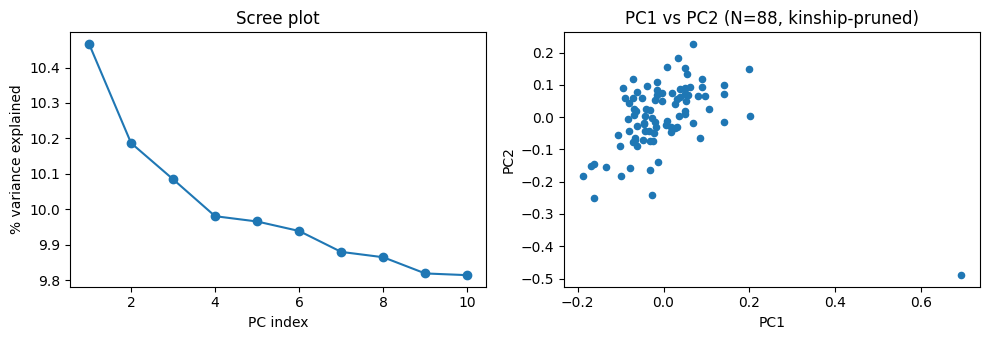

PCA computed on 88 donors (IID already = original_donor_id where available)


,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,PCMC-16-011,0.106044,0.023579,-0.027080,0.008177,-0.115807,0.128875,-0.109920,-0.322426,-0.107206,0.113281
1,PCMC-16-012,0.090394,0.092140,0.110455,0.086213,-0.069918,-0.016210,0.102693,-0.019238,0.107113,0.088199
2,PCMC-17-001,0.061562,0.094495,0.002568,-0.123315,-0.091964,0.119215,0.063628,0.183309,0.043034,0.033641
3,PCMC-17-005,-0.089989,0.058577,-0.151124,-0.204558,-0.056555,0.121525,0.124299,-0.073136,-0.226689,-0.215374
4,PCMC-17-006,-0.077173,-0.157476,0.007570,0.054672,0.099319,0.232668,-0.133970,0.158650,-0.324243,0.208904


,eigenval,PC,pct
0,1.13970,PC1,10.466641
1,1.10923,PC2,10.186814
2,1.09810,PC3,10.084600
3,1.08676,PC4,9.980457
4,1.08513,PC5,9.965488
5,1.08221,PC6,9.938671
6,1.07579,PC7,9.879712
7,1.07415,PC8,9.864651
8,1.06917,PC9,9.818916
9,1.06864,PC10,9.814049


<Axes: xlabel='PC1', ylabel='PC2'>

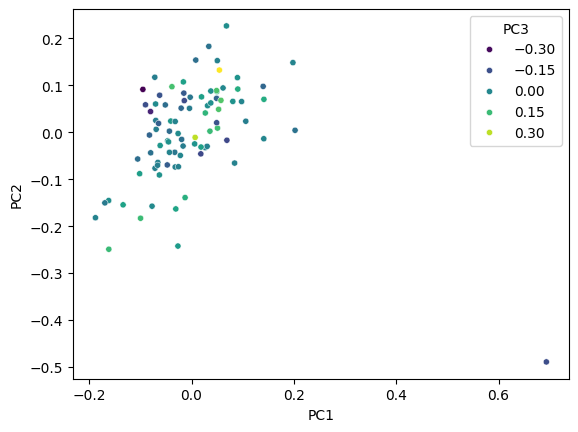

In [44]:
import matplotlib.pyplot as plt

pcs = pd.read_csv(f"{VCF_FOLDER}/{PCA_OUT}.eigenvec", sep=r"\s+")
pcs.columns = [c.lstrip("#") for c in pcs.columns]

eigenvals = pd.read_csv(f"{VCF_FOLDER}/{PCA_OUT}.eigenval", header=None, names=["eigenval"])
eigenvals["PC"]  = [f"PC{i+1}" for i in range(len(eigenvals))]
eigenvals["pct"] = eigenvals["eigenval"] / eigenvals["eigenval"].sum() * 100

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(range(1, len(eigenvals)+1), eigenvals["pct"], marker="o")
ax[0].set_xlabel("PC index"); ax[0].set_ylabel("% variance explained")
ax[0].set_title("Scree plot")
ax[1].scatter(pcs["PC1"], pcs["PC2"], s=20)
ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
ax[1].set_title(f"PC1 vs PC2 (N={len(pcs)}, kinship-pruned)")
plt.tight_layout(); plt.show()

print(f"PCA computed on {len(pcs)} donors (IID already = original_donor_id where available)")
display(pcs.head())
display(eigenvals)

import seaborn as sns
sns.scatterplot(data=pcs, x="PC1", y="PC2", hue="PC3", palette="viridis", s=20)


## Outputs — what to point the main GWAS notebook at

| Main notebook variable | Old (WGS) value | New (GSA) value |
|---|---|---|
| `SUBSET_NORM_VCF` (input to cell 23, plink2 conversion) | `subset/candidate.norm.bcf` | `GSA/subset/candidate.norm.bcf` |
| `PLINK_INFLAG` | `--vcf`/`--bcf` toggle | `--bcf` |
| `PCA_OUT` (skip cells 25–31 entirely, just load this) | `whole_xdp_PCA/PCA` | `GSA/whole_xdp_PCA/PCA` |

Cells that become **unnecessary** for GSA (already handled here):
- Cell 17 (contig-naming check) and cell 21 (chrom rename `1`→`chr1`) — GSA is already `chr`-prefixed.
- Cell 19 (donor-ID intersection) — samples are already subset + renamed to `original_donor_id`.
- Cells 25–31 (PCA + kinship) — precomputed above, on the kinship-pruned XDP GSA cohort.
- The commented-out `df_gwas = df_gwas[~df_gwas.index.isin(to_remove)]` line in the main
  notebook's kinship cell — **no longer needed**: related donors were already excluded from
  `SUBSET_NORM_VCF` and `PCA_OUT` here, so `df_gwas` built from either will already be
  relative-free. (It's still fine to leave that line active as a defensive double-check.)

One thing still worth a manual glance: `id_map` (Step 3) lists donors with **no** GSA match at
all, and any donor genotyped from **two tissues** (only one was kept, `_CB` preferred). And if
Step 5 printed a "both donors have snRNA-seq data" note, that specific pick was made arbitrarily
— revisit it if you'd rather keep the other member of that pair.
